<a href="https://colab.research.google.com/github/AtulSomkuwar/Reinforcement-Learning-Q-Learning/blob/main/Reinforcement_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

In [ ]:
# ----- ENVIRONMENT -----
class GridWorld:
    def __init__(self):
        self.rows, self.cols = 15, 15
        self.start = (0, 0)
        self.goal = (14, 14)
        self.obstacles = [(1,2),(2,4),(3,4),(7,4),(8,9),
                          (12,4),(7,7),(5,8),(10,4),(3,7),
                          (7,9),(2,5),(4,7),(5,7),(6,7),
                          (5,12),(7,12),(8,12),(10,12),(4,4),
                          (14,3),(14,5),(14,4),(14,7),(14,9),
                          (11,4),(11,6),(11,8),(11,10),(11,13),
                          (1,5),(1,6),(1,14),(1,8),(1,10),(1,12),
                          (1,9),(1,11),(0,14),(6,2),(6,3),(6,4),
                          (10,0),(10,1),(10,2),(2,9),(9,2),
                          (7,6),(8,6),(9,6),(10,6),(11,6),(12,6)]

        self.grid = np.zeros((self.rows, self.cols))
        self.grid[self.goal] = 10
        for o in self.obstacles:
            self.grid[o] = -10

        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        i, j = self.state

        if action == 0: i = max(0, i-1)  # UP
        elif action == 1: j = min(self.cols-1, j+1) # Right
        elif action == 2: i = min(self.rows-1, i+1) # Down
        elif action == 3: j = max(0, j-1) # Left

        self.state = (i, j)

        # Reward shaping
        if self.state == self.goal:
            return self.state, 10, True
        elif self.state in self.obstacles:
            return self.state, -10, True
        else:
            return self.state, -0.1, False

In [ ]:
# AGENT
class QAgent:
    def __init__(self, shape, lr=0.9, gamma=0.95, eps=1.0):
        self.q = np.zeros(shape + (4,))
        self.lr = lr
        self.gamma = gamma
        self.eps = eps

    def act(self, s):
        if random.random() < self.eps:
            return random.randint(0, 3)
        return np.argmax(self.q[s])

    def update(self, s, a, r, s2, done):
        target = r if done else r + self.gamma * np.max(self.q[s2]) # Bellman Equation
        self.q[s][a] += self.lr * (target - self.q[s][a]) # Moves Q-value closer to target

Episode 1: Reward = -10.7000
Episode 2: Reward = -11.5000
Episode 3: Reward = -14.0000
Episode 4: Reward = -10.7000
Episode 5: Reward = -10.6000
Episode 6: Reward = -12.3000
Episode 7: Reward = -10.7000
Episode 8: Reward = -10.7000
Episode 9: Reward = -14.4000
Episode 10: Reward = -11.7000
Episode 11: Reward = -13.8000
Episode 12: Reward = -16.5000
Episode 13: Reward = -13.7000
Episode 14: Reward = -11.1000
Episode 15: Reward = -12.6000
Episode 16: Reward = -11.0000
Episode 17: Reward = -10.9000
Episode 18: Reward = -10.7000
Episode 19: Reward = -11.9000
Episode 20: Reward = -11.1000
Episode 21: Reward = -12.2000
Episode 22: Reward = -14.4000
Episode 23: Reward = -12.0000
Episode 24: Reward = -14.4000
Episode 25: Reward = -14.3000
Episode 26: Reward = -11.2000
Episode 27: Reward = -11.7000
Episode 28: Reward = -11.6000
Episode 29: Reward = -14.3000
Episode 30: Reward = -13.0000
Episode 31: Reward = -11.0000
Episode 32: Reward = -10.5000
Episode 33: Reward = -12.6000
Episode 34: Reward 

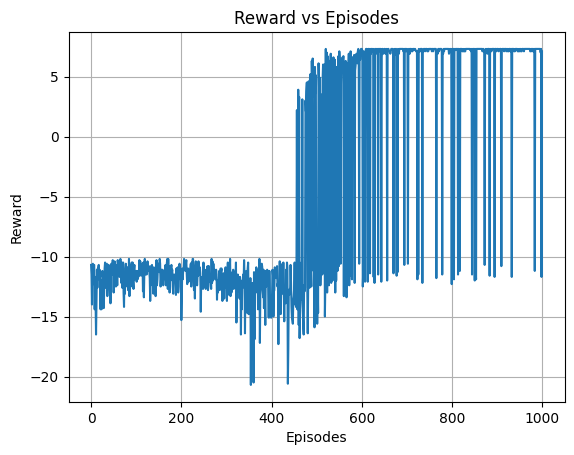

In [ ]:
# TRAINING
env = GridWorld()
agent = QAgent(env.grid.shape)

episodes = 1000
max_steps = 200

first_success_episode = None
best_reward = -float("inf")
best_path = []

# NEW: reward tracking
episode_rewards = []

for ep in range(1, episodes + 1):
    s = env.reset()
    total_reward = 0
    path = [s]

    for _ in range(max_steps):
        a = agent.act(s)
        s2, r, done = env.step(a)
        agent.update(s, a, r, s2, done)

        s = s2
        total_reward += r
        path.append(s)

        if done:
            if r == 10:
                if first_success_episode is None:
                    first_success_episode = ep

                if total_reward > best_reward:
                    best_reward = total_reward
                    best_path = path.copy()
            break


    episode_rewards.append(total_reward)

    print(f"Episode {ep}: Reward = {total_reward:.4f}")

    # epsilon decay
    agent.eps = max(0.01, agent.eps * 0.995)


print("\nTraining completed!")
print("First reached goal at episode:", first_success_episode)
print("Best reward:", best_reward)
print("Best path length:", len(best_path))


# REWARD GRAPH
plt.figure()

plt.plot(episode_rewards)
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Reward vs Episodes")
plt.grid()
plt.show()

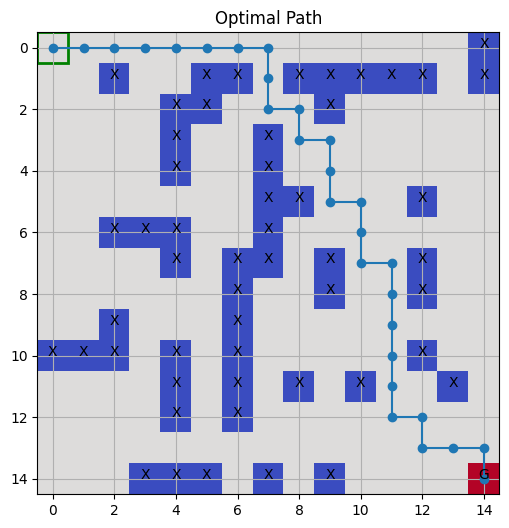

In [ ]:
# PLOT BEST PATH
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(env.grid, cmap='coolwarm')

for i in range(env.rows):
    for j in range(env.cols):
        if (i,j) == env.goal:
            ax.text(j, i, "G", ha='center')
        elif (i,j) in env.obstacles:
            ax.text(j, i, "X", ha='center')

# Start box
si, sj = env.start
rect = Rectangle((sj - 0.5, si - 0.5), 1, 1,
                 linewidth=2, edgecolor='green', facecolor='none')
ax.add_patch(rect)

# Draw path
ys = [p[0] for p in best_path]
xs = [p[1] for p in best_path]
ax.plot(xs, ys, marker='o')

plt.title("Optimal Path")
plt.grid(True)
plt.show()

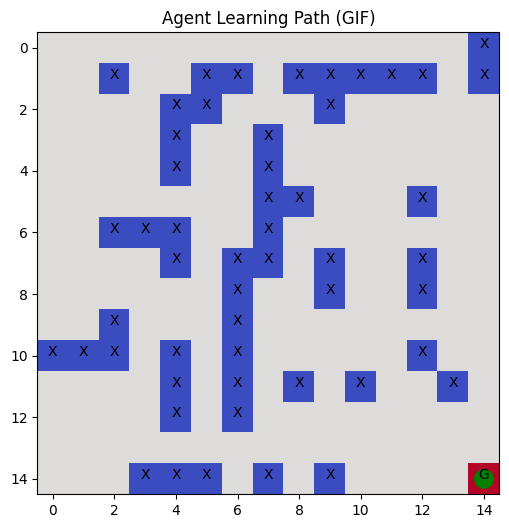

In [ ]:

import matplotlib.animation as animation

#  GIF ANIMATION SAVE
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(env.grid, cmap='coolwarm')

# Mark goal and obstacles
for i in range(env.rows):
    for j in range(env.cols):
        if (i,j) == env.goal:
            ax.text(j, i, "G", ha='center')
        elif (i,j) in env.obstacles:
            ax.text(j, i, "X", ha='center')

# Start position
si, sj = env.start

agent_dot = Circle((sj, si), 0.3, color='green')
ax.add_patch(agent_dot)

plt.title("Agent Learning Path (GIF)")

# Animation function
def update(frame):
    i, j = best_path[frame]
    agent_dot.center = (j, i)
    fig.canvas.draw_idle()
    return agent_dot,

# Animation
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(best_path),
    interval=1000,
    blit=False,
    repeat=False
)

# Save as GIF
ani.save("gridworld_path.gif", writer="pillow", fps=1)

plt.show()